Curator: Jamaal Porchia

Reviewer: HERE (Your team member's name)

Title: Stochastic Mathematical Modelling Study for Understanding the Extinction, Persistence and Control of SARS-CoV-2 Virus at the Within-host Level

Pathogen: SARS-CoV-2 Virus

DOI: https://doi.org/10.48550/arXiv.2405.06403

Figure: Figure 1a(Right)

Outcome: Successful

Notes: N/A

In [5]:
variable_names = [
    'S',
    'I',
    'B'
]
"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [
    'omega',
    'alpha',
    'beta',
    'p_value',
    'q',
    'mu',
    'mu1',
    'sigma1',
    'sigma2'

]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    S=100,
    I=100,
    B=100
)
"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""

parameter_values = dict(
    omega=10,
    alpha=0.24,
    beta=0.005,
    p_value=0.795,
    q=0.28,
    mu=0.1,
    mu1=0.6,
    sigma1=0.1,
    sigma2=0.1
)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 20.0
"""Final time to simulate during testing and curation of the SDE model."""


def drift_term(t, y, param):
    """The drift term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """
    S, I, B = y

    omega, alpha, beta, p_value, q, mu, mu1, sigma1, sigma2 = param

    dS = (omega - beta*S*B - mu*S)
    dI = (beta*S*B - p_value*I - mu*I)
    dB = (alpha*I - q*B - mu1*B) 

    return[dS, dI, dB]


def diffusion_term(t, y, param):
    """The diffusion term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """
    S, I, B = y

    omega, alpha, beta, p_value, q, mu, mu1, sigma1, sigma2 = param

    diff_S = -sigma1 * S
    diff_I = -sigma1 * I 
    diff_B = -sigma2 * B

    return[diff_S, diff_I, diff_B]

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

In [6]:
missing_ics = [n for n in variable_names if n not in initial_values]
missing_params = [n for n in parameter_names if n not in parameter_values]

found_errors = False
if len(missing_ics) > 0:
    print(f"Error: Missing initial values for variables: {missing_ics}")
    found_errors = True
if len(missing_params) > 0:
    print(f"Error: Missing values for parameters: {missing_params}")
    found_errors = True
test_drift = drift_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
test_diffusion = diffusion_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
if len(test_drift) != len(variable_names):
    print(f"Error: The drift term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_drift)}.")
    found_errors = True
if len(test_diffusion) != len(variable_names):
    print(f"Error: The diffusion term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_diffusion)}.")
    found_errors = True
if found_errors:
    raise ValueError("Failed to define the SDE model.")

## Do simulation test

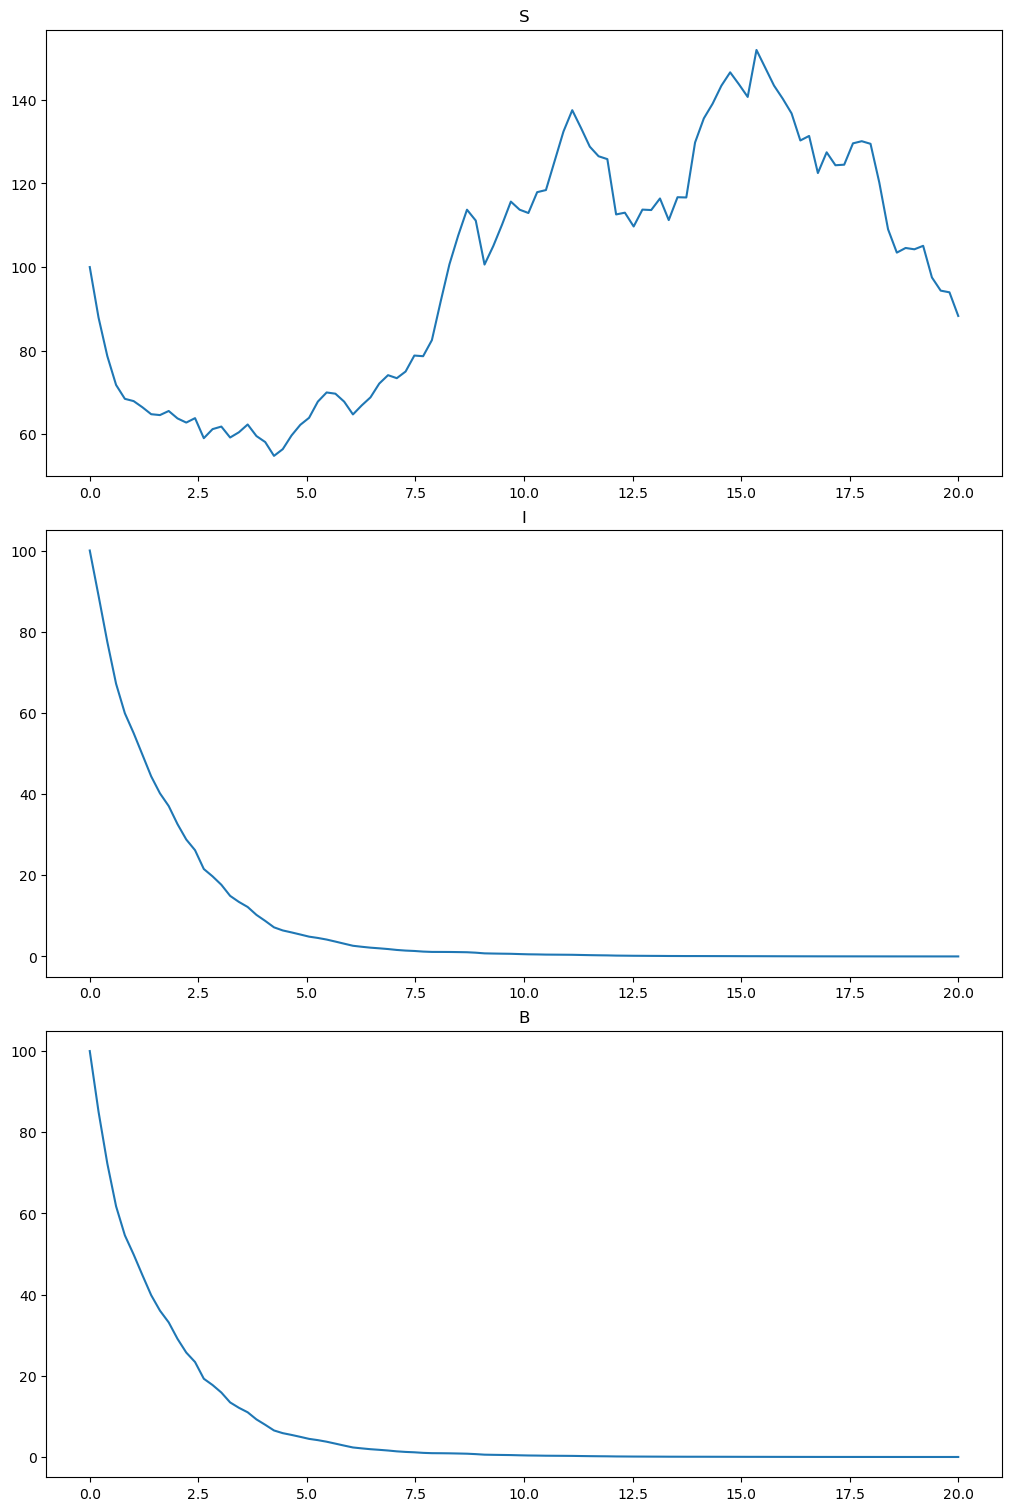

In [7]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")
for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [8]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
